# SAVIA — Demo del DAO
## Sistema de Almacenamiento de Índices de Vegetación con Inteligencia Agrícola
### Proyecto Integrador Bases de Datos II · UNdeC 2026

Este notebook demuestra el funcionamiento del módulo `VinedoDAO` —
la capa de acceso a datos del sistema SAVIA.

In [1]:
from dao import VinedoDAO
from datetime import date
import matplotlib.pyplot as plt

dao = VinedoDAO()
print("Conexión establecida con MongoDB")
print(f"Base de datos: vinedos_chilecito")

Conexión establecida con MongoDB
Base de datos: vinedos_chilecito


In [2]:
# Consulta por zona
parcelas_nonogasta = dao.get_parcelas_por_zona("Nonogasta")
print(f"Parcelas en Nonogasta: {len(parcelas_nonogasta)}")
for p in parcelas_nonogasta:
    print(f"  - {p['nombre']} | {p['variedad']} | {p['superficie_ha']} ha")

# Consulta por cultivo
parcelas_vid = dao.get_parcelas_por_cultivo("vid")
print(f"\nTotal parcelas de vid: {len(parcelas_vid)}")
for p in parcelas_vid:
    print(f"  - {p['nombre']} ({p['zona']})")

Parcelas en Nonogasta: 1
  - Finca El Peñón | Torrontés Riojano | 3.8 ha

Total parcelas de vid: 4
  - Finca El Peñón (Nonogasta)
  - Finca Los Sarmientos Norte (Los Sarmientos)
  - Viña Famatina (Famatina)
  - Finca Vichigasta Sur (Vichigasta)


In [3]:
# Recuperar una parcela por id y agregar una observación nueva
parcela = parcelas_vid[0]
parcela_id = str(parcela["_id"])

print(f"Parcela seleccionada: {parcela['nombre']}")
print(f"ID: {parcela_id}")

# Agregar una observación nueva
nueva_obs = dao.agregar_observacion(
    parcela_id=parcela_id,
    observacion=__import__('db_models').Observacion(
        fecha=date(2024, 3, 18),
        ndvi=0.22,
        evi=0.16,
        ndwi=0.06,
        nubosidad_pct=2.1
    )
)
print(f"\nObservación agregada: {nueva_obs}")

Parcela seleccionada: Finca El Peñón
ID: 69ed44d17861560994b926b1

Observación agregada: True


In [4]:
# Consultar serie temporal completa
observaciones = dao.get_observaciones(parcela_id)
print(f"Total observaciones: {len(observaciones)}")
print("\nPrimeras 3:")
for o in observaciones[:3]:
    print(f"  {o['fecha']} | NDVI: {o['ndvi']} | EVI: {o['evi']} | Nubosidad: {o['nubosidad_pct']}%")

# Consultar por rango de fechas
obs_verano = dao.get_observaciones(
    parcela_id,
    desde=date(2023, 12, 1),
    hasta=date(2024, 2, 28)
)
print(f"\nObservaciones en verano (dic-feb): {len(obs_verano)}")

Total observaciones: 14

Primeras 3:
  2023-09-05 | NDVI: 0.31 | EVI: 0.22 | Nubosidad: 3.2%
  2023-09-20 | NDVI: 0.38 | EVI: 0.27 | Nubosidad: 7.1%
  2023-10-05 | NDVI: 0.45 | EVI: 0.33 | Nubosidad: 2.8%

Observaciones en verano (dic-feb): 6


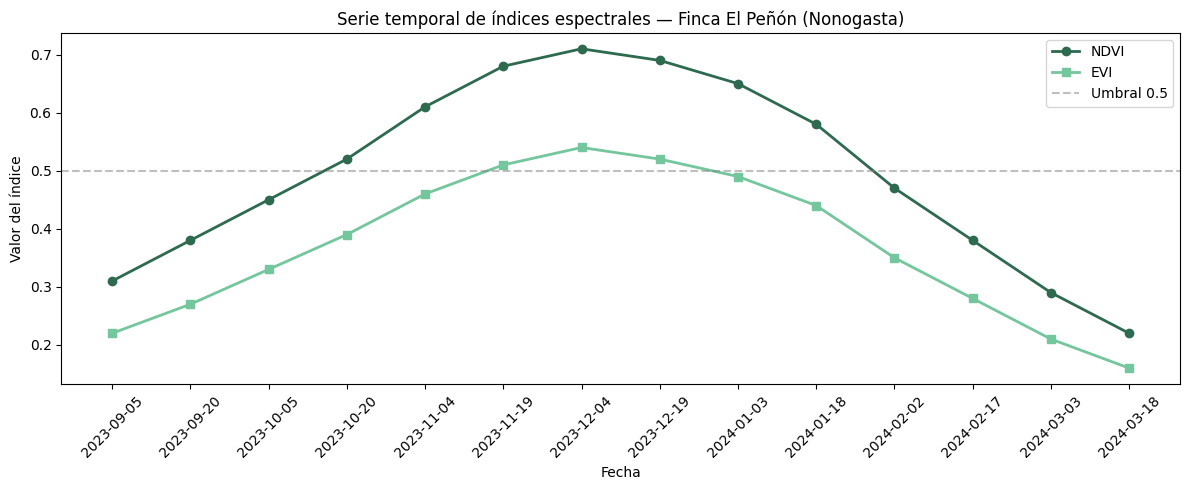

In [5]:
fechas = [o["fecha"] for o in observaciones]
ndvi_vals = [o["ndvi"] for o in observaciones]
evi_vals = [o["evi"] for o in observaciones]

plt.figure(figsize=(12, 5))
plt.plot(fechas, ndvi_vals, marker="o", label="NDVI", color="#2d6a4f", linewidth=2)
plt.plot(fechas, evi_vals, marker="s", label="EVI", color="#74c69d", linewidth=2)
plt.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Umbral 0.5")
plt.title("Serie temporal de índices espectrales — Finca El Peñón (Nonogasta)")
plt.xlabel("Fecha")
plt.ylabel("Valor del índice")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# NDVI promedio por zona para la temporada 2023/2024
resultado = dao.get_ndvi_promedio_por_zona("Nonogasta", "2023/2024")
for r in resultado:
    print(f"Zona: {r['_id']}")
    print(f"  NDVI promedio: {r['ndvi_promedio']:.4f}")
    print(f"  Total observaciones: {r['total_observaciones']}")

Zona: Nonogasta
  NDVI promedio: 0.4957
  Total observaciones: 14


In [7]:
# Campañas registradas
campanas = dao.get_campanas(parcela_id)
print(f"Historial de cosechas — Finca El Peñón")
print("-" * 45)
for c in campanas:
    print(f"Temporada: {c['temporada']}")
    print(f"  Cosecha:      {c['fecha_cosecha']}")
    print(f"  Rendimiento:  {c['rendimiento_kg_ha']} kg/ha")
    print(f"  Notas:        {c['notas']}")

dao.cerrar()
print("\nConexión cerrada.")

Historial de cosechas — Finca El Peñón
---------------------------------------------
Temporada: 2023/2024
  Cosecha:      2024-02-28
  Rendimiento:  8400 kg/ha
  Notas:        Sin eventos climáticos adversos. Riego controlado desde noviembre.

Conexión cerrada.
